# Avaliação do Modelo — CreditGuard AI

Carrega o modelo salvo em  e avalia seu desempenho no conjunto de teste.
O split é recriado deterministicamente com  a partir do .

In [1]:
import pandas as pd
import numpy as np
import joblib
import yaml
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

In [2]:
with open("Model/config.yaml", "r") as f:
    model_cfg = yaml.safe_load(f)

with open("DataPipeline/config.yaml", "r") as f:
    pipeline_cfg = yaml.safe_load(f)

model    = joblib.load(model_cfg["artifacts"]["model"])
features = joblib.load(model_cfg["artifacts"]["features"])

print("Modelo carregado:", model_cfg["artifacts"]["model"])
print("Features:", len(features), "colunas")

Modelo carregado: Model/artifacts/xgb_balanced_model.joblib
Features: 119 colunas


In [3]:
df = pd.read_csv(pipeline_cfg["paths"]["abt"])

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=model_cfg["split"]["test_size"],
    random_state=model_cfg["split"]["random_state"],
    stratify=y
)

print("Conjunto de teste:", X_test.shape)

Conjunto de teste: (61503, 119)


## Métricas de Avaliação

In [4]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc     = roc_auc_score(y_test, y_proba)
gini        = 2 * roc_auc - 1
ks          = float(np.max(tpr - fpr))

metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall"   : recall_score(y_test, y_pred),
    "F1-Score" : f1_score(y_test, y_pred),
    "ROC-AUC"  : roc_auc,
    "Gini"     : gini,
    "KS"       : ks,
}

print("Modelo: XGBoost Balanced (candidato a producao)")
print()
for k, v in metrics.items():
    print(f"  {k:12}: {v:.4f}")

Modelo: XGBoost Balanced (candidato a producao)

  Accuracy    : 0.7049
  Precision   : 0.1655
  Recall      : 0.6568
  F1-Score    : 0.2643
  ROC-AUC     : 0.7509
  Gini        : 0.5019
  KS          : 0.3694


## Matriz de Confusão

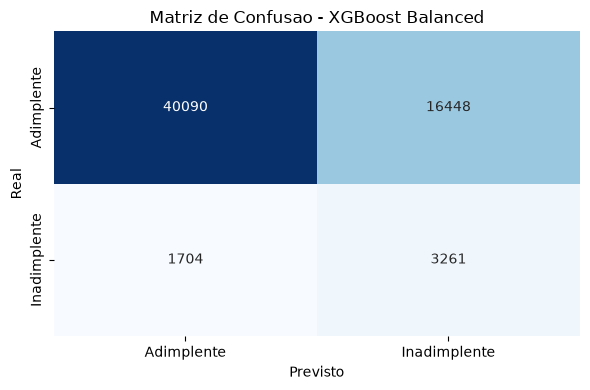

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Adimplente", "Inadimplente"],
    yticklabels=["Adimplente", "Inadimplente"],
    ax=ax
)
ax.set_title("Matriz de Confusao - XGBoost Balanced")
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## Curva ROC

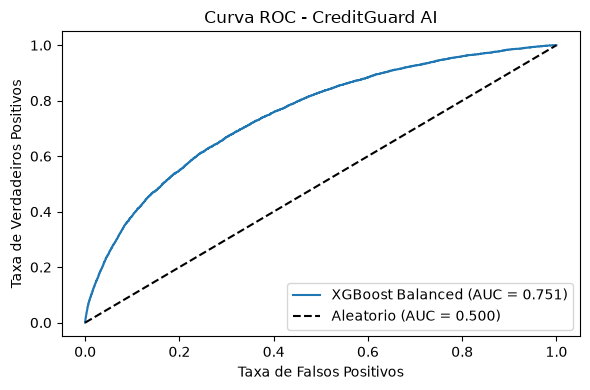

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr, tpr, label="XGBoost Balanced (AUC = " + f"{roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Aleatorio (AUC = 0.500)")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curva ROC - CreditGuard AI")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusao

O modelo **XGBoost Balanced** e o candidato atual para producao:

| Metrica   | Valor  |
|-----------|--------|
| Accuracy  | 0.7049 |
| Precision | 0.1655 |
| Recall    | 0.6568 |
| F1-Score  | 0.2643 |
| ROC-AUC   | 0.7509 |
| Gini      | 0.5019 |
| KS        | 0.3694 |

O Recall elevado e prioritario: o custo de conceder credito a um inadimplente supera o custo de negar credito a um bom pagador.